# Modeling Foreign Exchange Risk using GARCH-Type Models and Value-at-Risk

**Research question.** Can the GARCH model and its extensions improve the estimation of
market risk for major EUR-denominated currency pairs compared to a simple historical
volatility approach, and to what extent does the choice of conditional-variance
specification and innovation distribution affect Value-at-Risk (VaR) forecast accuracy?

**Design.** For each of three EUR pairs (EUR/USD, EUR/GBP, EUR/CHF) we fit 3 conditional
variance models by 3 innovation distributions, i.e. 9 specifications, plus a
non-parametric Historical-Simulation benchmark.


## 1. Setup

Run once to install the runtime dependencies (`arch` for GARCH models, `yfinance` for data) in case if not installed yet

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import yfinance as yf
from arch import arch_model
from arch.univariate import GARCH, EGARCH

plt.rcParams.update({
    "figure.figsize": (11, 4),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})
RNG = np.random.default_rng(42)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## 2. Configuration


In [3]:
PAIRS = {
    "EUR/USD": "EURUSD=X",
    "EUR/GBP": "EURGBP=X",
    "EUR/CHF": "EURCHF=X",
}

START_DATE = "2015-03-01"
END_DATE   = "2026-06-01"

# variance specifications. arch encodes GJR as GARCH with an asymmetry term o=1.
VOL_MODELS = {
    "GARCH":     dict(vol="GARCH",  p=1, o=0, q=1),   # symmetric
    "EGARCH":    dict(vol="EGARCH", p=1, o=1, q=1),   # asymmetric (log-variance)
    "GJR-GARCH": dict(vol="GARCH",  p=1, o=1, q=1),   # asymmetric (threshold)
}

# innovation distributions
DISTS = {"Gaussian": "normal", "Student-t": "t", "Skewed-t": "skewt"}

# VaR confidence levels 
VAR_LEVELS = {"95%": 0.05, "99%": 0.01}

# out-of-sample rolling-window estimation

ROLL_WINDOW = 1000   # fixed estimation-sample length
REFIT_EVERY = 5      # re-estimate parameters every k steps

# returns are scaled by 100 (percent) for numerical stability in arch
SCALE = 100.0

## 3. Data loading and preprocessing 

Daily quotes from Yahoo Finance, transformed into log-returns
$r_t = 100\cdot\ln(P_t / P_{t-1})$.

In [4]:
def download_prices(pairs, start, end):
    frames = {}
    for name, ticker in pairs.items():
        df = yf.download(ticker, start=start, end=end,
                         auto_adjust=True, progress=False)
        px = df["Close"]
        if isinstance(px, pd.DataFrame):      
            px = px.iloc[:, 0]
        frames[name] = px.rename(name)
    prices = pd.concat(frames.values(), axis=1)
    return prices.dropna(how="all")

prices = download_prices(PAIRS, START_DATE, END_DATE)
returns = (np.log(prices).diff() * SCALE).dropna()
print(f"Prices: {prices.shape[0]} obs,  {prices.index.min().date()} -> {prices.index.max().date()}")
returns.tail()

Prices: 2928 obs,  2015-03-02 -> 2026-05-29


,EUR/USD,EUR/GBP,EUR/CHF
Date,,,
2026-05-25,0.1815,-0.1620,-0.3212
2026-05-26,-0.0419,-0.1762,0.0692
2026-05-27,-0.0047,0.3185,0.2510
2026-05-28,-0.1628,0.1340,0.1651
2026-05-29,0.3002,0.0577,-0.1980


In [5]:
# descriptive statistics of the log-returns
desc = returns.describe().T
desc["skew"] = returns.skew()
desc["kurtosis"] = returns.kurtosis()         
desc["JB p-value"] = [stats.jarque_bera(returns[c])[1] for c in returns.columns]
desc[["mean", "std", "min", "max", "skew", "kurtosis", "JB p-value"]]

,mean,std,min,max,skew,kurtosis,JB p-value
EUR/USD,0.0015,0.4892,-2.8144,2.8145,0.0936,2.6659,0.0000
EUR/GBP,0.0060,0.5495,-11.0504,11.0116,0.4498,114.6900,0.0000
EUR/CHF,-0.0052,0.3189,-1.9773,1.7099,-0.1333,2.3984,0.0000


### Figure 1 — Daily log-returns

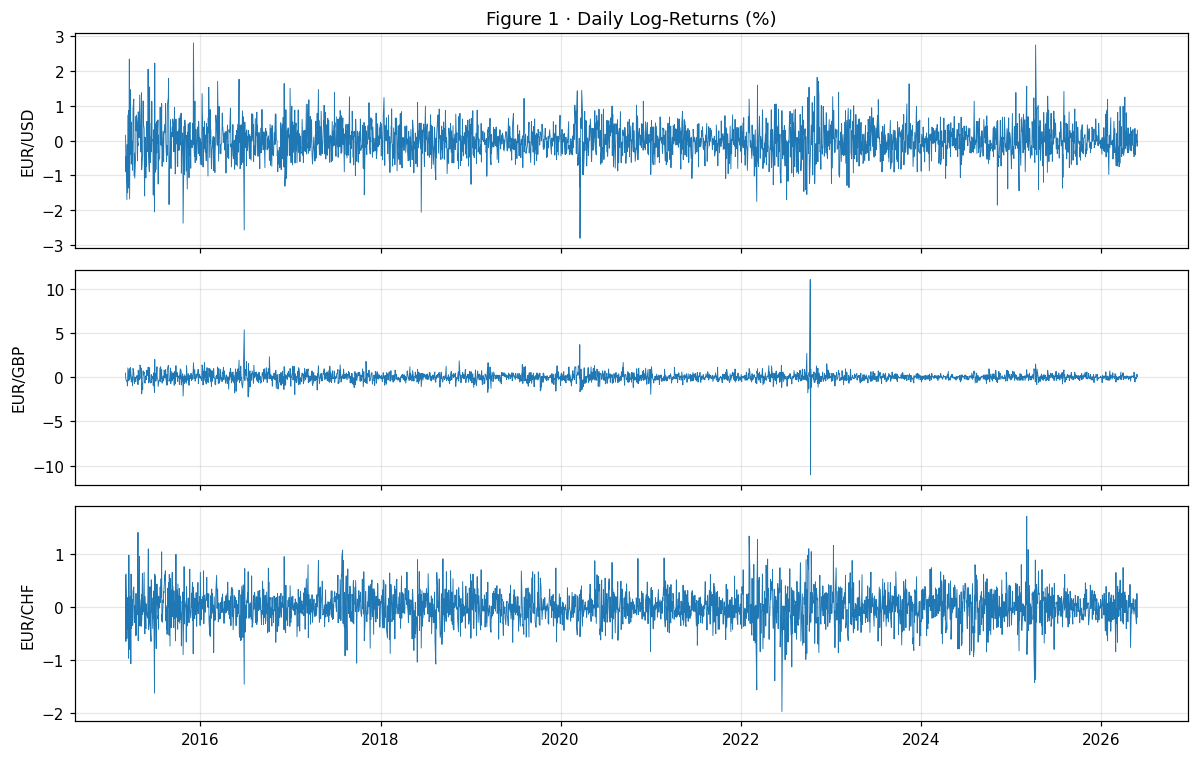

In [6]:
fig, axes = plt.subplots(len(returns.columns), 1, figsize=(11, 7), sharex=True)
for ax, col in zip(axes, returns.columns):
    ax.plot(returns.index, returns[col], lw=0.6)
    ax.set_ylabel(col)
axes[0].set_title("Figure 1 · Daily Log-Returns (%)")
plt.tight_layout(); plt.show()

### Figure 2 — Squared returns (volatility proxy)

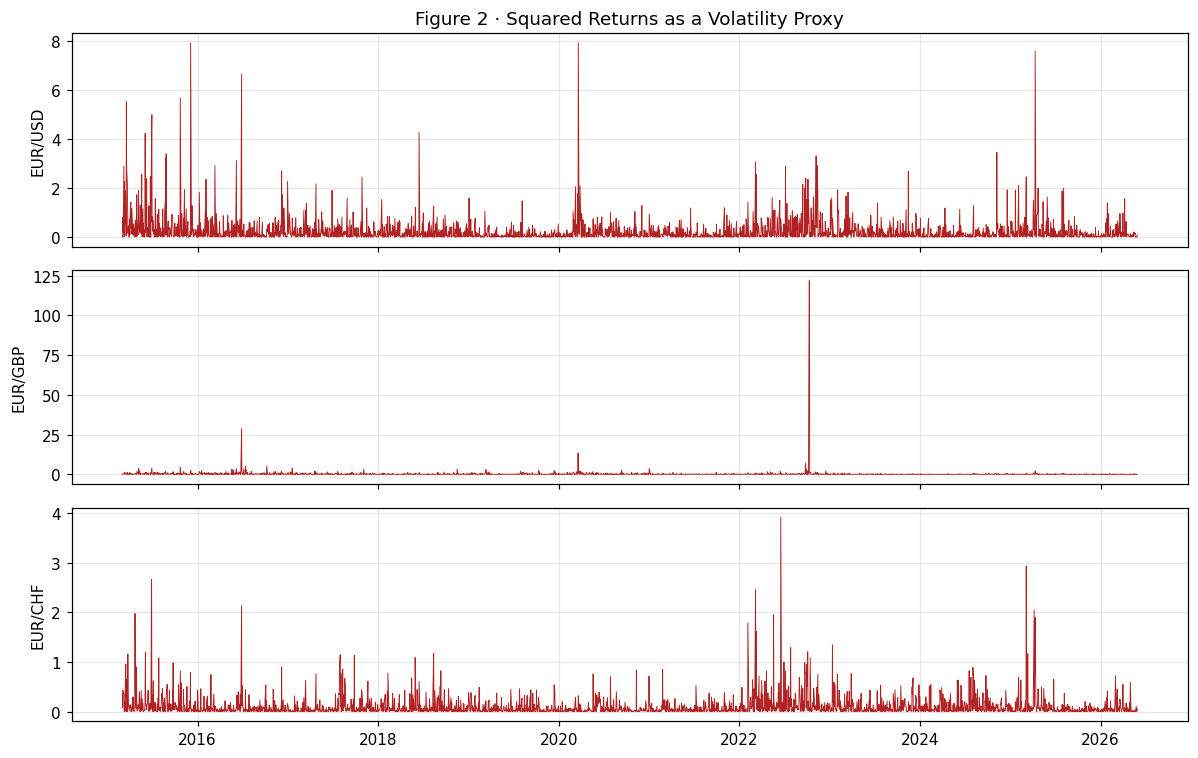

In [7]:
fig, axes = plt.subplots(len(returns.columns), 1, figsize=(11, 7), sharex=True)
for ax, col in zip(axes, returns.columns):
    ax.plot(returns.index, returns[col] ** 2, lw=0.6, color="firebrick")
    ax.set_ylabel(col)
axes[0].set_title("Figure 2 · Squared Returns as a Volatility Proxy")
plt.tight_layout(); plt.show()

## 3. Pre-model diagnostics

### 3.1. Stationarity

In [8]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import het_arch, acorr_ljungbox

def adf_summary(y, name, regression="c"):
    """ADF test with automatic lag selection by AIC."""
    stat, pval, lags, nobs, crit, _ = adfuller(y.dropna().values,
                                               regression=regression,
                                               autolag="AIC")
    return {
        "Series": name,
        "ADF stat": stat,
        "p-value": pval,
        "lags (AIC)": lags,
        "n obs": nobs,
        "1% crit": crit["1%"],
        "5% crit": crit["5%"],
        "10% crit": crit["10%"],
        "Stationary (5%)?": "Yes" if pval < 0.05 else "No",
    }

adf_rows = [adf_summary(returns[c], c) for c in returns.columns]
adf_table = pd.DataFrame(adf_rows)
print("=== Augmented Dickey-Fuller test on log-returns ===")
print("H0: unit root (non-stationary). Reject (p < 0.05) -> series is stationary.")
display(adf_table.round(4))

=== Augmented Dickey-Fuller test on log-returns ===
H0: unit root (non-stationary). Reject (p < 0.05) -> series is stationary.


,Series,ADF stat,p-value,lags (AIC),n obs,1% crit,5% crit,10% crit,Stationary (5%)?
0,EUR/USD,-23.9527,0.0000,5,2919,-3.4326,-2.8625,-2.5673,Yes
1,EUR/GBP,-29.7610,0.0000,3,2921,-3.4326,-2.8625,-2.5673,Yes
2,EUR/CHF,-20.7626,0.0000,7,2917,-3.4326,-2.8625,-2.5673,Yes


### 3.2. Anomaly spikes in volatility
This section identifies the largest absolute daily log-returns for each currency pair.  
These observations represent unusually strong exchange-rate movements and are relevant for tail-risk analysis.  

In [9]:
spikes = []

for pair in returns.columns:
    temp = returns[pair].dropna().to_frame("return")
    temp["abs_return"] = temp["return"].abs()
    top = temp.sort_values("abs_return", ascending=False).head(5).reset_index()
    top["pair"] = pair
    spikes.append(top)

spikes_table = pd.concat(spikes, ignore_index=True)
spikes_table

,Date,return,abs_return,pair
0,2015-12-04,2.8145,2.8145,EUR/USD
1,2020-03-20,-2.8144,2.8144,EUR/USD
2,2025-04-11,2.7537,2.7537,EUR/USD
3,2016-06-27,-2.5767,2.5767,EUR/USD
4,2015-10-23,-2.3817,2.3817,EUR/USD
5,2022-10-11,-11.0504,11.0504,EUR/GBP
6,2022-10-10,11.0116,11.0116,EUR/GBP
7,2016-06-27,5.3527,5.3527,EUR/GBP
8,2020-03-19,3.6620,3.6620,EUR/GBP
9,2022-09-26,2.6774,2.6774,EUR/GBP


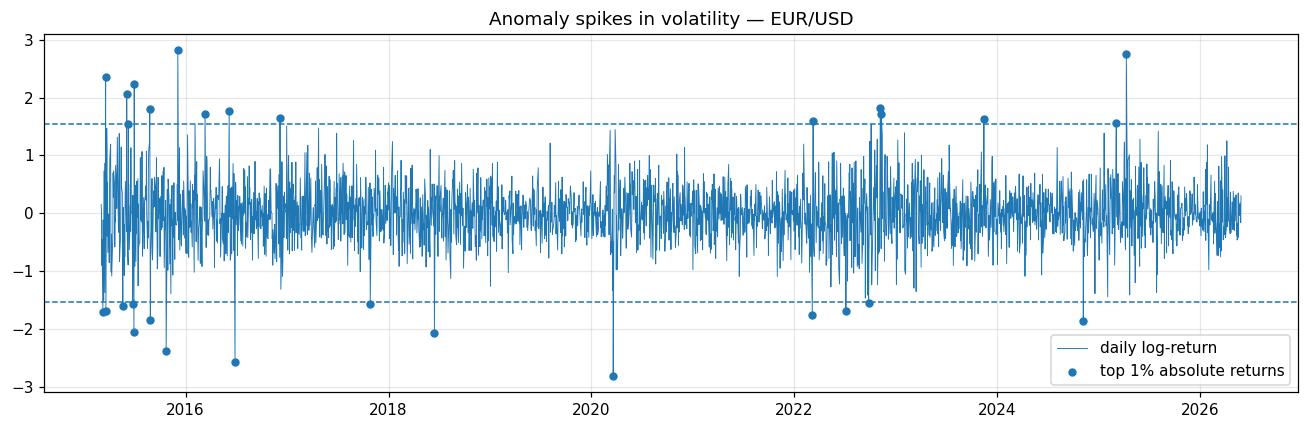

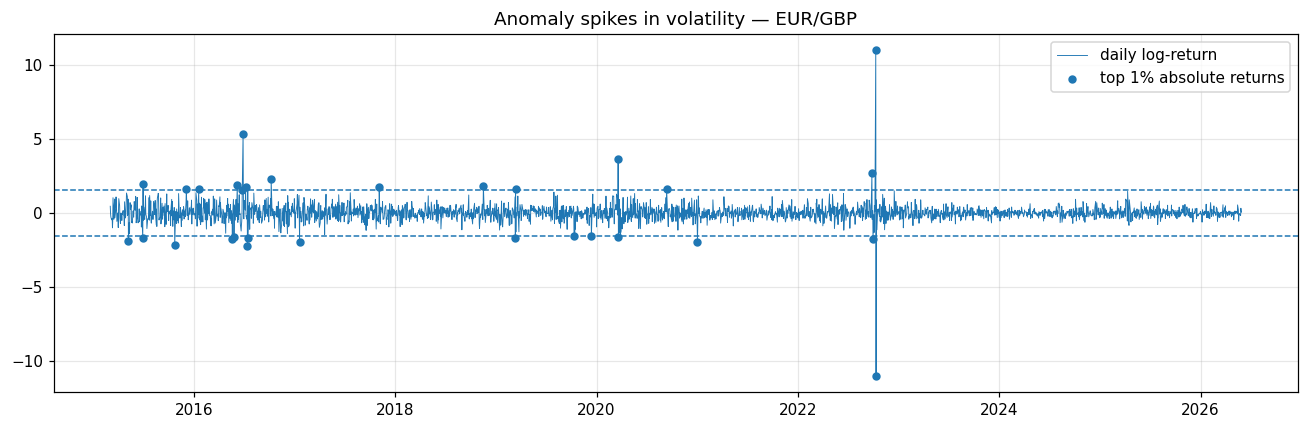

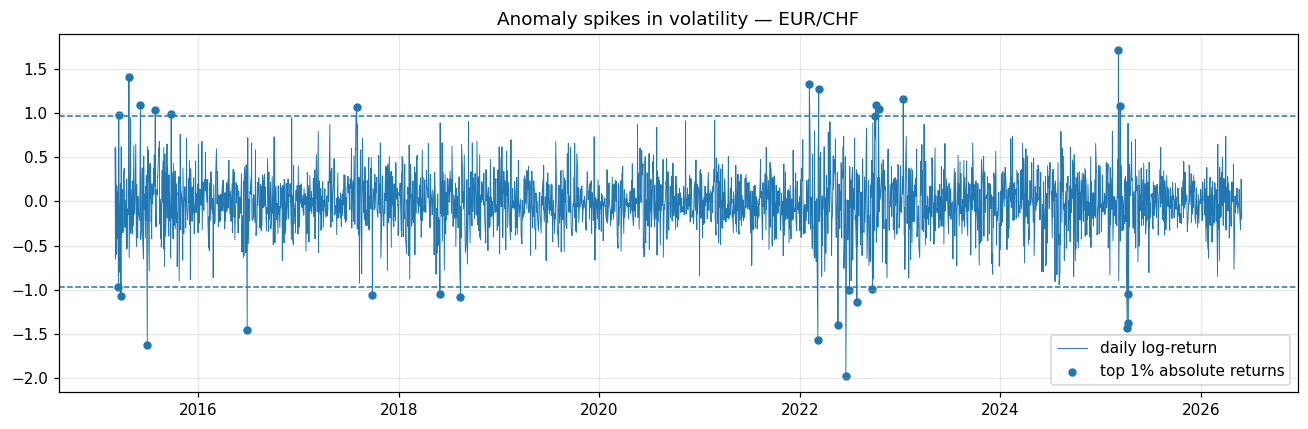

In [10]:
for pair in returns.columns:
    temp = returns[pair].dropna()
    threshold = temp.abs().quantile(0.99)

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(temp.index, temp, lw=0.6, label="daily log-return")
    ax.scatter(
        temp[temp.abs() > threshold].index,
        temp[temp.abs() > threshold],
        s=20,
        label="top 1% absolute returns"
    )
    ax.axhline(threshold, linestyle="--", lw=1)
    ax.axhline(-threshold, linestyle="--", lw=1)
    ax.set_title(f"Anomaly spikes in volatility — {pair}")
    ax.legend()
    plt.tight_layout()
    plt.show()

The anomaly spike analysis shows that all three exchange-rate return series contain periods of unusually large absolute returns. This supports the presence of volatility clustering and tail risk in FX markets. <br> The EUR/CHF series displays the most extreme negative return, which is consistent with the heavy-tailed behavior observed in the Q-Q plots. These findings motivate the use of GARCH-type models and fat-tailed innovation distributions for Value-at-Risk forecasting.

## 4. In-sample estimation of the nine specifications

Helper that builds and fits one (variance model, distribution) specification on a
return series. A constant-mean model is used.

In [11]:
import warnings
from arch.utility.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

def build_model(y, vol_key, dist_key):

    spec = VOL_MODELS[vol_key]
    return arch_model(
        y, mean="Constant",
        vol=spec["vol"], p=spec["p"], o=spec["o"], q=spec["q"],
        dist=DISTS[dist_key],
    )

def fit_all(y):
  
    fits = {}
    for vol_key in VOL_MODELS:
        for dist_key in DISTS:
            res = build_model(y, vol_key, dist_key).fit(disp="off")
            fits[(vol_key, dist_key)] = res
    return fits

# fit every specification for every currency pair (in-sample, full history)
insample = {pair: fit_all(returns[pair]) for pair in returns.columns}
print("Fitted", sum(len(v) for v in insample.values()), "models across",
      len(insample), "currency pairs.")

Fitted 27 models across 3 currency pairs.


### 4.1 Q-Q plots of standardized residuals vs Normal and Student-t

If Gaussian innovations were correct, the standardized residual
$\hat z_t = (r_t - \hat\mu)/\hat\sigma_t$ from the GARCH(1,1)/Gaussian fit would lie on the diagonal line of the Normal Q-Q plot. Tail-curvature away from the line at the extremes is the visual signature of fat tails — and the empirical case for switching to Student-t (or skewed-t) innovations.

For each pair we plot $\hat z_t$ against four reference distributions on the multiple plot below.

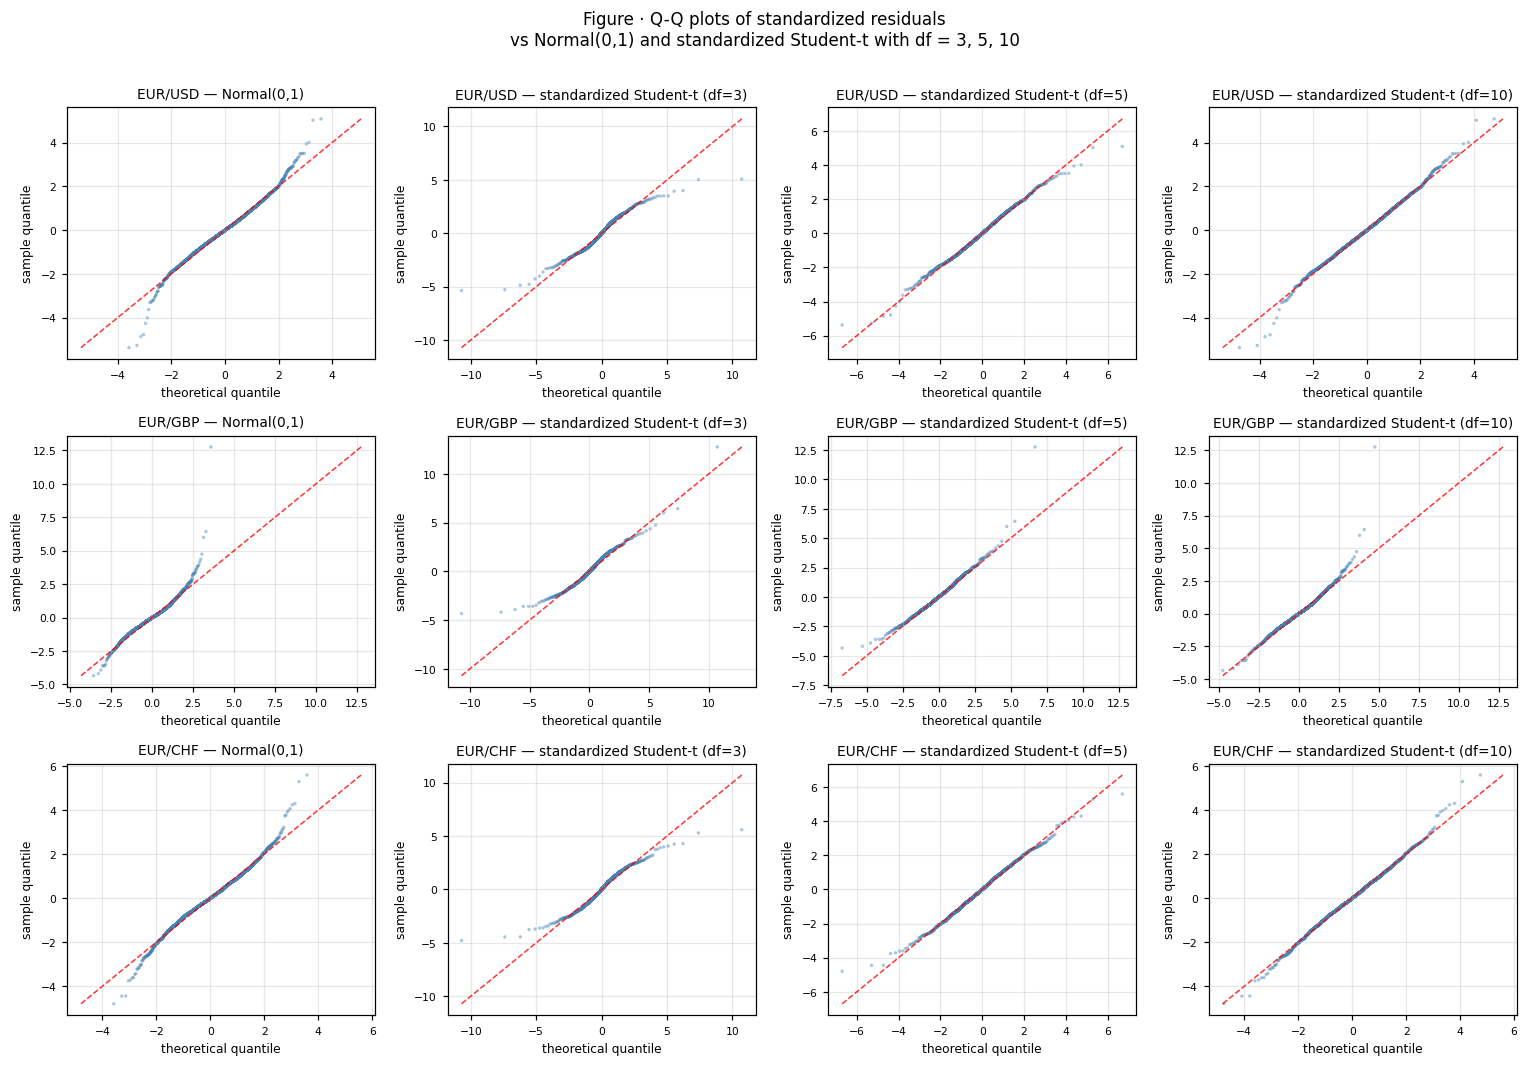


Fitted Student-t degrees of freedom (GARCH(1,1)/Student-t):
  EUR/USD : nu =  7.17
  EUR/GBP : nu =  4.79
  EUR/CHF : nu =  6.46


In [12]:
QQ_DFS = [3, 5, 10]   # degree of freedom options


def std_t_ppf(p, df): # quantile function of the std Student-t 

    return stats.t.ppf(p, df=df) * np.sqrt((df - 2.0) / df)


def qq_panel(ax, sample, dist_ppf, title): #single Q-Q panel
    
    z = np.sort(np.asarray(sample, dtype=float))
    n = len(z)
    p = (np.arange(1, n + 1) - 0.5) / n       
    tq = dist_ppf(p)
    ax.scatter(tq, z, s=5, alpha=0.45, color="steelblue", edgecolors="none")
    lo = float(np.nanmin([tq.min(), z.min()]))
    hi = float(np.nanmax([tq.max(), z.max()]))
    ax.plot([lo, hi], [lo, hi], "r--", lw=1.0, alpha=0.8, label="y = x")
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("theoretical quantile", fontsize=8)
    ax.set_ylabel("sample quantile", fontsize=8)
    ax.tick_params(labelsize=7)

n_pairs = len(returns.columns)
fig, axes = plt.subplots(n_pairs, 1 + len(QQ_DFS),
                         figsize=(14, 3.2 * n_pairs))

for i, pair in enumerate(returns.columns):
    z = pd.Series(insample[pair][("GARCH", "Gaussian")].std_resid).dropna().values

    # column 0 — Normal
    qq_panel(axes[i, 0], z, stats.norm.ppf, f"{pair} — Normal(0,1)")

    # columns 1-3 — standardized t(df)
    for j, df in enumerate(QQ_DFS, start=1):
        qq_panel(axes[i, j], z,
                 lambda p, df=df: std_t_ppf(p, df),
                 f"{pair} — standardized Student-t (df={df})")

fig.suptitle(
    "Figure · Q-Q plots of standardized residuals\n"
    "vs Normal(0,1) and standardized Student-t with df = 3, 5, 10",
    fontsize=11, y=1.005,
)
plt.tight_layout()
plt.show()

print("\nFitted Student-t degrees of freedom (GARCH(1,1)/Student-t):")
for pair in returns.columns:
    nu = float(insample[pair][("GARCH", "Student-t")].params["nu"])
    print(f"  {pair:8s}: nu = {nu:5.2f}")

### Table 2 — Estimated model parameters

In [13]:
def params_table(fits):
    cols = {}
    for (vol_key, dist_key), res in fits.items():
        cols[f"{vol_key}/{dist_key}"] = res.params
    return pd.DataFrame(cols)

for pair in returns.columns:
    print(f"\n=== Table 2 · {pair} — estimated GARCH-type model parameters ===")
    display(params_table(insample[pair]).round(4).T)


=== Table 2 · EUR/USD — estimated GARCH-type model parameters ===


,alpha[1],beta[1],eta,gamma[1],lambda,mu,nu,omega
GARCH/Gaussian,0.0323,0.9591,NaN,NaN,NaN,-0.0009,NaN,0.0019
GARCH/Student-t,0.0307,0.9618,NaN,NaN,NaN,-0.0041,7.1687,0.0016
GARCH/Skewed-t,0.0307,0.9615,7.1689,NaN,0.0341,-0.0010,NaN,0.0016
EGARCH/Gaussian,0.0811,0.9904,NaN,-0.0101,NaN,0.0003,NaN,-0.0123
EGARCH/Student-t,0.0771,0.9917,NaN,-0.0053,NaN,-0.0039,7.1817,-0.0106
EGARCH/Skewed-t,0.0774,0.9914,7.1803,-0.0046,0.0346,-0.0007,NaN,-0.0110
GJR-GARCH/Gaussian,0.0318,0.9592,NaN,0.0010,NaN,-0.0011,NaN,0.0019
GJR-GARCH/Student-t,0.0310,0.9616,NaN,-0.0006,NaN,-0.0040,7.1677,0.0016
GJR-GARCH/Skewed-t,0.0313,0.9614,7.1671,-0.0009,0.0342,-0.0009,NaN,0.0017



=== Table 2 · EUR/GBP — estimated GARCH-type model parameters ===


,alpha[1],beta[1],eta,gamma[1],lambda,mu,nu,omega
GARCH/Gaussian,0.1152,0.8848,NaN,NaN,NaN,0.0024,NaN,0.0028
GARCH/Student-t,0.0921,0.8965,NaN,NaN,NaN,-0.0069,4.7881,0.0037
GARCH/Skewed-t,0.0938,0.8934,4.8972,NaN,0.0736,0.0007,NaN,0.0039
EGARCH/Gaussian,0.2402,0.9863,NaN,0.0307,NaN,0.0071,NaN,-0.0047
EGARCH/Student-t,0.1179,0.9877,NaN,0.0320,NaN,-0.0028,4.8450,-0.0146
EGARCH/Skewed-t,0.1230,0.9859,4.9436,0.0379,0.0824,0.0060,NaN,-0.0168
GJR-GARCH/Gaussian,0.1337,0.8886,NaN,-0.0447,NaN,0.0063,NaN,0.0027
GJR-GARCH/Student-t,0.1133,0.8985,NaN,-0.0508,NaN,-0.0048,4.7804,0.0037
GJR-GARCH/Skewed-t,0.1195,0.8945,4.8795,-0.0576,0.0802,0.0038,NaN,0.0041



=== Table 2 · EUR/CHF — estimated GARCH-type model parameters ===


,alpha[1],beta[1],eta,gamma[1],lambda,mu,nu,omega
GARCH/Gaussian,0.0434,0.9383,NaN,NaN,NaN,-0.0056,NaN,0.0018
GARCH/Student-t,0.0570,0.9245,NaN,NaN,NaN,-0.0060,6.4585,0.0019
GARCH/Skewed-t,0.0570,0.9244,6.4567,NaN,0.0020,-0.0059,NaN,0.0019
EGARCH/Gaussian,0.1156,0.9772,NaN,0.0059,NaN,-0.0063,NaN,-0.0500
EGARCH/Student-t,0.1422,0.9754,NaN,0.0082,NaN,-0.0065,6.4530,-0.0529
EGARCH/Skewed-t,0.1422,0.9754,6.4521,0.0082,0.0011,-0.0064,NaN,-0.0529
GJR-GARCH/Gaussian,0.0463,0.9387,NaN,-0.0059,NaN,-0.0051,NaN,0.0017
GJR-GARCH/Student-t,0.0597,0.9249,NaN,-0.0058,NaN,-0.0057,6.4562,0.0019
GJR-GARCH/Skewed-t,0.0598,0.9249,6.4540,-0.0059,0.0027,-0.0055,NaN,0.0019


### Figure 3 — Estimated conditional volatility

Annualized conditional volatility from the Student-t variants of the three variance
models (distribution choice barely moves $\sigma_t$; it mainly affects the tail quantile).

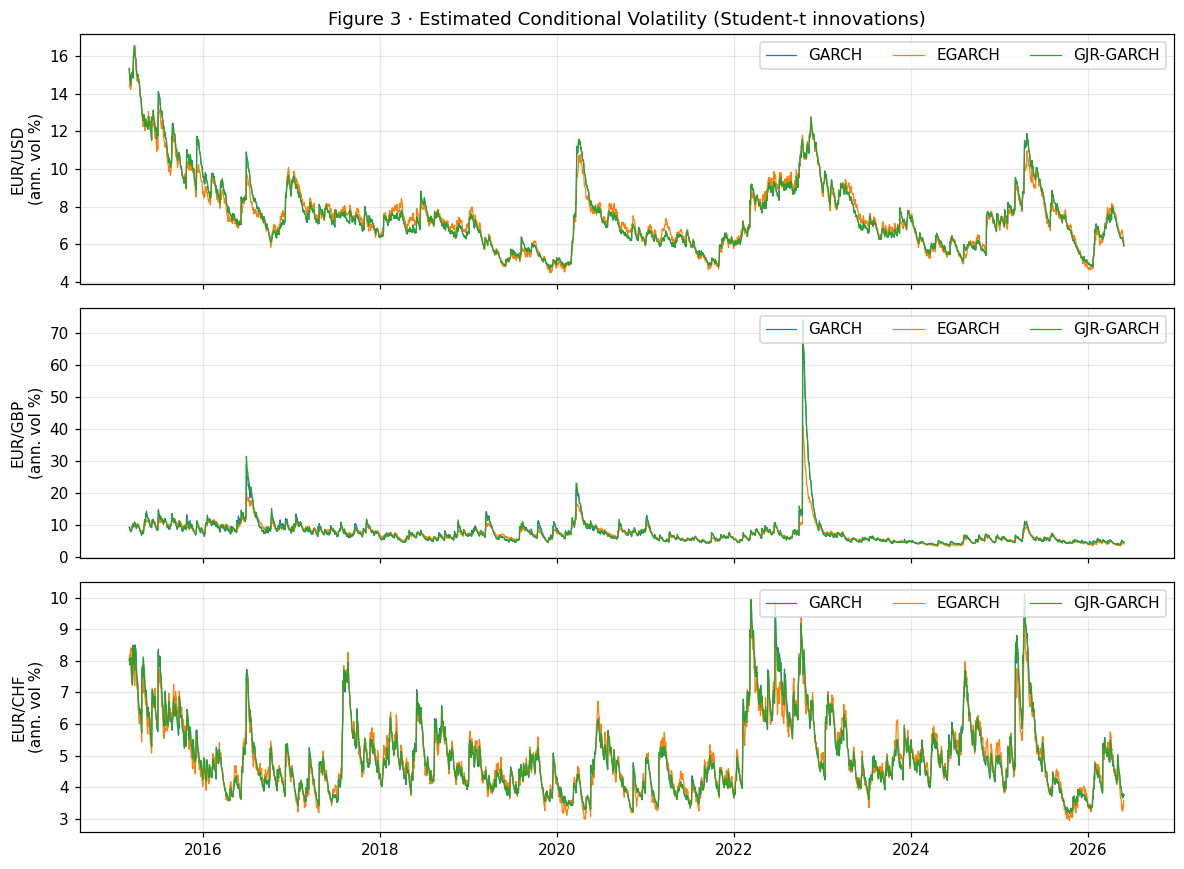

In [14]:
fig, axes = plt.subplots(len(returns.columns), 1, figsize=(11, 8), sharex=True)
for ax, pair in zip(axes, returns.columns):
    for vol_key in VOL_MODELS:
        res = insample[pair][(vol_key, "Student-t")]
        ann_vol = res.conditional_volatility * np.sqrt(252) / SCALE * 100
        ax.plot(returns[pair].index, ann_vol, lw=0.8, label=vol_key)
    ax.set_ylabel(f"{pair}\n(ann. vol %)"); ax.legend(loc="upper right", ncol=3)
axes[0].set_title("Figure 3 · Estimated Conditional Volatility (Student-t innovations)")
plt.tight_layout(); plt.show()

## 5 · Out-of-sample rolling-window forecasting

Each specification is re-estimated on a fixed-size moving sample of ROLL_WINDOW days
and produces a one-step-ahead VaR forecast. REFIT_EVERY controls how often parameters are
re-estimated.

In [15]:
import os
import warnings as _warnings
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

def dist_shape_params(res):
    names = res.model.distribution.parameter_names()
    return np.asarray([res.params[n] for n in names], dtype=float)


def rolling_var_forecasts(y, vol_key, dist_key, alpha_map,
                          window=ROLL_WINDOW, refit_every=REFIT_EVERY):

    y = y.dropna()
    n = len(y)
    out_idx, rows = [], []
    last_res = None

    for t in range(window, n):
        train = y.iloc[t - window:t]

        if (t - window) % refit_every == 0 or last_res is None:
            last_res = build_model(train, vol_key, dist_key).fit(
                disp="off",
                show_warning=False,
                options={"maxiter": 1000}
            )

            shape = dist_shape_params(last_res)
            zq = {
                lvl: last_res.model.distribution.ppf(a, shape)
                for lvl, a in alpha_map.items()
            }

        fc = last_res.forecast(horizon=1, reindex=False)

        mu = float(fc.mean.iloc[-1, 0])
        sigma = float(np.sqrt(fc.variance.iloc[-1, 0]))

        row = {
            f"VaR_{lvl}": mu + sigma * zq[lvl]
            for lvl in alpha_map
        }

        row["realized"] = y.iloc[t]
        rows.append(row)
        out_idx.append(y.index[t])

    return pd.DataFrame(rows, index=out_idx)


# 9 model-distribution specifications
ALL_SPECS = [(v, d) for v in VOL_MODELS for d in DISTS]

# 3 currency pairs × 9 specifications = 27 rolling tasks
TASKS = [
    (pair, v, d)
    for pair in returns.columns
    for (v, d) in ALL_SPECS
]


def _worker(task):
    pair, vol_key, dist_key = task

    with _warnings.catch_warnings():
        _warnings.simplefilter("ignore")
        fc = rolling_var_forecasts(
            returns[pair],
            vol_key,
            dist_key,
            VAR_LEVELS
        )

    return pair, vol_key, dist_key, fc


MAX_WORKERS = min(len(TASKS), max(2, (os.cpu_count() or 4) - 1))

oos_all = {pair: {} for pair in returns.columns}

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
    futures = {ex.submit(_worker, t): t for t in TASKS}

    pbar = tqdm(
        as_completed(futures),
        total=len(futures),
        desc=f"Rolling VaR (threads={MAX_WORKERS})",
        unit="spec"
    )

    for fut in pbar:
        pair, vol_key, dist_key, fc = fut.result()
        oos_all[pair][f"{vol_key}/{dist_key}"] = fc
        pbar.set_postfix_str(
            f"{pair} · {vol_key}/{dist_key} ({len(fc)} fcs)"
        )

n_done = sum(len(v) for v in oos_all.values())

print(f"\nFinished: {n_done} (pair × spec) forecasts across {len(oos_all)} pairs.")

DRAFT_PAIR = "EUR/USD"
oos = oos_all[DRAFT_PAIR]

Rolling VaR (threads=15): 100%|██████████| 27/27 [26:02<00:00, 57.89s/spec, EUR/CHF · GJR-GARCH/Skewed-t (1925 fcs)] 


Finished: 27 (pair × spec) forecasts across 3 pairs.


In [16]:
def gof_table(fits):
    rows = []

    for (vol_key, dist_key), res in fits.items():
        rows.append({
            "Model": vol_key,
            "Distribution": dist_key,
            "LogLik": res.loglikelihood,
            "AIC": res.aic,
            "BIC": res.bic,
            "n_params": len(res.params),
        })

    return (
        pd.DataFrame(rows)
        .sort_values("AIC")
        .reset_index(drop=True)
    )


gof = {pair: gof_table(fits) for pair, fits in insample.items()}

for pair, table in gof.items():
    print(f"\n=== Table 3 · {pair} — goodness of fit (sorted by AIC) ===")
    display(table)


=== Table 3 · EUR/USD — goodness of fit (sorted by AIC) ===


,Model,Distribution,LogLik,AIC,BIC,n_params
0,GARCH,Student-t,"-1,839.6237","3,689.2474","3,719.1527",5
1,GARCH,Skewed-t,"-1,838.7683","3,689.5366","3,725.4229",6
2,GJR-GARCH,Student-t,"-1,839.6214","3,691.2429","3,727.1292",6
3,GJR-GARCH,Skewed-t,"-1,838.7639","3,691.5278","3,733.3952",7
4,EGARCH,Student-t,"-1,841.3881","3,694.7762","3,730.6625",6
5,EGARCH,Skewed-t,"-1,840.5101","3,695.0202","3,736.8875",7
6,GARCH,Gaussian,"-1,901.6864","3,811.3728","3,835.2970",4
7,GJR-GARCH,Gaussian,"-1,901.6787","3,813.3574","3,843.2627",5
8,EGARCH,Gaussian,"-1,903.1844","3,816.3687","3,846.2740",5



=== Table 3 · EUR/GBP — goodness of fit (sorted by AIC) ===


,Model,Distribution,LogLik,AIC,BIC,n_params
0,EGARCH,Skewed-t,"-1,523.9804","3,061.9608","3,103.8281",7
1,EGARCH,Student-t,"-1,529.2429","3,070.4859","3,106.3722",6
2,GJR-GARCH,Skewed-t,"-1,545.9129","3,105.8257","3,147.6931",7
3,GARCH,Skewed-t,"-1,549.7663","3,111.5325","3,147.4188",6
4,GJR-GARCH,Student-t,"-1,551.1142","3,114.2284","3,150.1147",6
5,GARCH,Student-t,"-1,554.2033","3,118.4067","3,148.3119",5
6,GJR-GARCH,Gaussian,"-1,730.1387","3,470.2774","3,500.1826",5
7,GARCH,Gaussian,"-1,733.0452","3,474.0905","3,498.0147",4
8,EGARCH,Gaussian,"-1,732.9613","3,475.9226","3,505.8278",5



=== Table 3 · EUR/CHF — goodness of fit (sorted by AIC) ===


,Model,Distribution,LogLik,AIC,BIC,n_params
0,GARCH,Student-t,-606.2878,"1,222.5757","1,252.4809",5
1,GJR-GARCH,Student-t,-606.2017,"1,224.4033","1,260.2896",6
2,GARCH,Skewed-t,-606.2849,"1,224.5699","1,260.4562",6
3,GJR-GARCH,Skewed-t,-606.1964,"1,226.3927","1,268.2601",7
4,EGARCH,Student-t,-609.0234,"1,230.0468","1,265.9331",6
5,EGARCH,Skewed-t,-609.0225,"1,232.0451","1,273.9124",7
6,GARCH,Gaussian,-674.1416,"1,356.2831","1,380.2073",4
7,GJR-GARCH,Gaussian,-673.9683,"1,357.9366","1,387.8419",5
8,EGARCH,Gaussian,-676.6663,"1,363.3325","1,393.2378",5


### Figure 5 — VaR forecasts vs. realized returns

Realized returns with the 95% and 99% rolling VaR forecasts; red dots mark 99% violations.

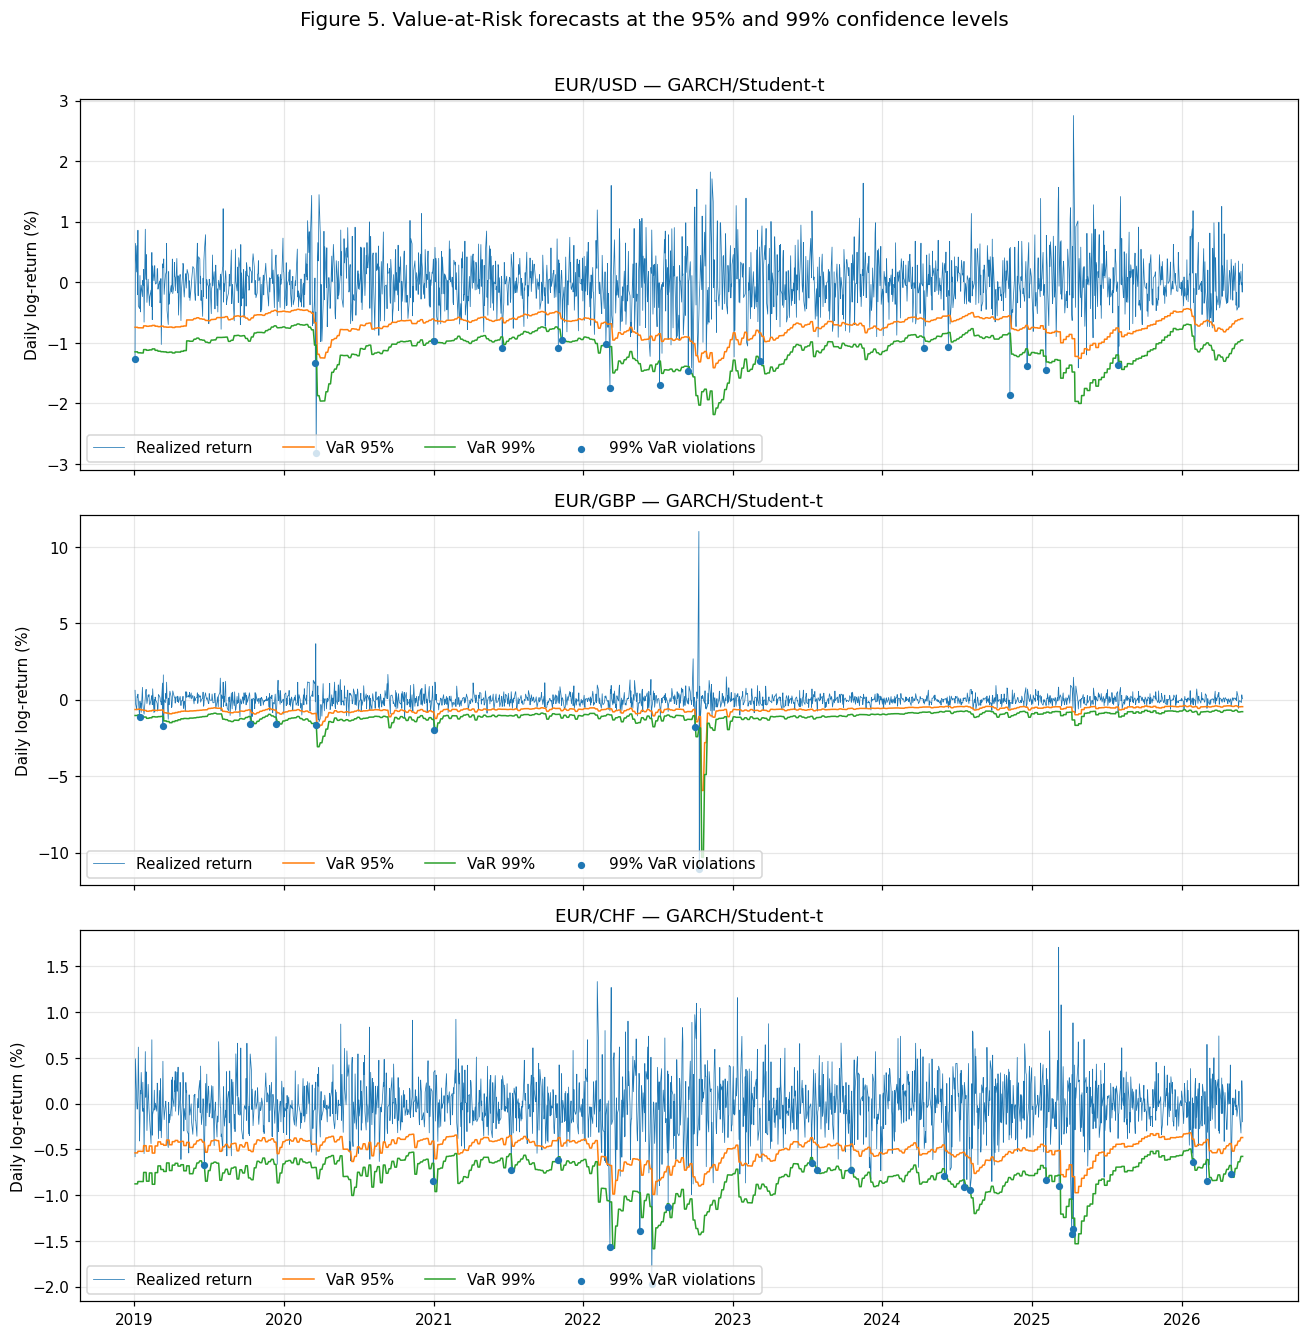

In [17]:
PLOT_SPEC = "GARCH/Student-t"   # or "GJR-GARCH/Skewed-t"

fig, axes = plt.subplots(
    len(returns.columns),
    1,
    figsize=(12, 4 * len(returns.columns)),
    sharex=True
)

if len(returns.columns) == 1:
    axes = [axes]

for ax, pair in zip(axes, returns.columns):
    demo = oos_all[pair][PLOT_SPEC].dropna()

    ax.plot(
        demo.index,
        demo["realized"],
        lw=0.5,
        label="Realized return"
    )

    ax.plot(
        demo.index,
        demo["VaR_95%"],
        lw=1.0,
        label="VaR 95%"
    )

    ax.plot(
        demo.index,
        demo["VaR_99%"],
        lw=1.0,
        label="VaR 99%"
    )

    viol_99 = demo[demo["realized"] < demo["VaR_99%"]]

    ax.scatter(
        viol_99.index,
        viol_99["realized"],
        s=14,
        zorder=5,
        label="99% VaR violations"
    )

    ax.set_title(f"{pair} — {PLOT_SPEC}")
    ax.set_ylabel("Daily log-return (%)")
    ax.legend(loc="lower left", ncol=4)

fig.suptitle(
    "Figure 5. Value-at-Risk forecasts at the 95% and 99% confidence levels",
    fontsize=13,
    y=1.01
)

plt.tight_layout()
plt.show()

### Historical VaR baseline

In [18]:
oos_all

{'EUR/USD': {'EGARCH/Gaussian':             VaR_95%  VaR_99%  realized
  2019-01-03  -0.0050  -0.0050   -1.2608
  2019-01-04  -0.0050  -0.0050    0.6427
  2019-01-07  -0.0050  -0.0050    0.1699
  2019-01-08  -0.0050  -0.0050    0.6054
  2019-01-09  -0.0050  -0.0050   -0.2064
  ...             ...      ...       ...
  2026-05-25  -0.6592  -0.9358    0.1815
  2026-05-26  -0.6592  -0.9358   -0.0419
  2026-05-27  -0.6592  -0.9358   -0.0047
  2026-05-28  -0.6592  -0.9358   -0.1628
  2026-05-29  -0.6592  -0.9358    0.3002
  
  [1925 rows x 3 columns],
  'GARCH/Gaussian':             VaR_95%  VaR_99%  realized
  2019-01-03  -0.7325  -1.0376   -1.2608
  2019-01-04  -0.7325  -1.0376    0.6427
  2019-01-07  -0.7325  -1.0376    0.1699
  2019-01-08  -0.7325  -1.0376    0.6054
  2019-01-09  -0.7325  -1.0376   -0.2064
  ...             ...      ...       ...
  2026-05-25  -0.6295  -0.8930    0.1815
  2026-05-26  -0.6295  -0.8930   -0.0419
  2026-05-27  -0.6295  -0.8930   -0.0047
  2026-05-28  -0.629

In [19]:
def historical_var_forecasts(y, alpha_map, window=ROLL_WINDOW):
    y = y.dropna()

    rows = []
    out_idx = []

    for t in range(window, len(y)):
        train = y.iloc[t - window:t]

        row = {}
        for lvl, alpha in alpha_map.items():
            row[f"VaR_{lvl}"] = train.quantile(alpha)

        row["realized"] = y.iloc[t]

        rows.append(row)
        out_idx.append(y.index[t])

    return pd.DataFrame(rows, index=out_idx)


# Add Historical VaR to all currency pairs
for pair in returns.columns:
    oos_all[pair]["Historical VaR"] = historical_var_forecasts(
        returns[pair],
        VAR_LEVELS,
        window=ROLL_WINDOW
    )

print("Historical VaR added.")

Historical VaR added.


## 6 · VaR backtesting

### 6.1 Violations summary

In [20]:
def var_violation_summary(forecasts, alpha_map):
    rows = []

    for lvl, alpha in alpha_map.items():
        var_col = f"VaR_{lvl}"

        data = forecasts[["realized", var_col]].dropna()

        realized = data["realized"]
        var = data[var_col]

        violations = realized < var

        n = len(violations)
        x = int(violations.sum())

        rows.append({
            "VaR level": lvl,
            "alpha": alpha,
            "n forecasts": n,
            "expected violations": n * alpha,
            "actual violations": x,
            "actual violation rate": x / n
        })

    return pd.DataFrame(rows)

### 6.2 Kupiec Test

This test checks whether the observed number of VaR violations is consistent with the expected violation rate.

In [21]:
from scipy.stats import chi2
def kupiec_test(forecasts, var_col, alpha):
    data = forecasts[["realized", var_col]].dropna()
    hits = (data["realized"] < data[var_col]).astype(int)

    n = len(hits)
    x = int(hits.sum())

    if x == 0 or x == n:
        return {"LR_uc": np.nan, "p_value_uc": np.nan}

    phat = x / n

    logL_null = (n - x) * np.log(1 - alpha) + x * np.log(alpha)
    logL_alt = (n - x) * np.log(1 - phat) + x * np.log(phat)

    LR_uc = -2 * (logL_null - logL_alt)
    p_value = 1 - chi2.cdf(LR_uc, df=1)

    return {"LR_uc": LR_uc, "p_value_uc": p_value}

### 6.3 Christoffersen_test

This test checks whether VaR violations occur independently over time.


In [22]:
def christoffersen_test(forecasts, var_col):
    data = forecasts[["realized", var_col]].dropna()
    hits = (data["realized"] < data[var_col]).astype(int).values

    h_prev = hits[:-1]
    h_curr = hits[1:]

    n00 = np.sum((h_prev == 0) & (h_curr == 0))
    n01 = np.sum((h_prev == 0) & (h_curr == 1))
    n10 = np.sum((h_prev == 1) & (h_curr == 0))
    n11 = np.sum((h_prev == 1) & (h_curr == 1))

    pi01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
    pi = (n01 + n11) / (n00 + n01 + n10 + n11)

    def xlogx(count, prob):
        return count * np.log(prob) if count > 0 and prob > 0 else 0

    logL_ind = (
        xlogx(n00, 1 - pi01) +
        xlogx(n01, pi01) +
        xlogx(n10, 1 - pi11) +
        xlogx(n11, pi11)
    )

    logL_null = (
        xlogx(n00 + n10, 1 - pi) +
        xlogx(n01 + n11, pi)
    )

    LR_ind = -2 * (logL_null - logL_ind)
    p_value_ind = 1 - chi2.cdf(LR_ind, df=1)

    return {
        "LR_ind": LR_ind,
        "p_value_ind": p_value_ind,
        "n00": n00,
        "n01": n01,
        "n10": n10,
        "n11": n11
    }

### 6.4 DQ-test

This test checks whether VaR violations are predictable from past information. A good VaR model should produce violations that are not systematically related to previous violations or past market conditions.


In [23]:
def dq_test(forecasts, var_col, alpha, lags=4):
    data = forecasts[["realized", var_col]].dropna().copy()

    data["hit"] = (data["realized"] < data[var_col]).astype(int)
    data["hit_centered"] = data["hit"] - alpha

    for lag in range(1, lags + 1):
        data[f"hit_lag_{lag}"] = data["hit_centered"].shift(lag)

    data = data.dropna()

    if len(data) <= lags + 1:
        return {"DQ stat": np.nan, "DQ p-value": np.nan, "DQ df": np.nan}

    y = data["hit_centered"].values
    X = data[[f"hit_lag_{lag}" for lag in range(1, lags + 1)]].values
    X = np.column_stack([np.ones(len(X)), X])

    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    y_hat = X @ beta

    dq_stat = (y_hat @ y_hat) / (alpha * (1 - alpha))
    df = X.shape[1]
    p_value = 1 - chi2.cdf(dq_stat, df=df)

    return {
        "DQ stat": dq_stat,
        "DQ p-value": p_value,
        "DQ df": df
    }

In [24]:
def backtest_var_model(pair, model_name, forecasts, alpha_map):
    rows = []

    for lvl, alpha in alpha_map.items():
        var_col = f"VaR_{lvl}"

        data = forecasts[["realized", var_col]].dropna()
        violations = data["realized"] < data[var_col]

        n = len(violations)
        x = int(violations.sum())

        kupiec = kupiec_test(forecasts, var_col, alpha)
        christ = christoffersen_test(forecasts, var_col)
        dq = dq_test(forecasts, var_col, alpha, lags=4)

        rows.append({
            "Pair": pair,
            "Model": model_name,
            "VaR level": lvl,
            "alpha": alpha,
            "n forecasts": n,
            "expected violations": n * alpha,
            "actual violations": x,
            "actual violation rate": x / n,
            "Kupiec p-value": kupiec["p_value_uc"],
            "Christoffersen p-value": christ["p_value_ind"],
            "DQ p-value": dq["DQ p-value"],
            "DQ stat": dq["DQ stat"]
        })

    return rows


backtest_rows = []

for pair in oos_all:
    for model_name, forecasts in oos_all[pair].items():
        backtest_rows.extend(
            backtest_var_model(
                pair,
                model_name,
                forecasts,
                VAR_LEVELS
            )
        )

backtesting_table = pd.DataFrame(backtest_rows)

backtesting_table["Kupiec decision"] = np.where(
    backtesting_table["Kupiec p-value"] >= 0.05,
    "Pass",
    "Reject"
)

backtesting_table["Christoffersen decision"] = np.where(
    backtesting_table["Christoffersen p-value"] >= 0.05,
    "Pass",
    "Reject"
)

backtesting_table["DQ decision"] = np.where(
    backtesting_table["DQ p-value"] >= 0.05,
    "Pass",
    "Reject"
)

backtesting_table

,Pair,Model,VaR level,alpha,n forecasts,expected violations,actual violations,actual violation rate,Kupiec p-value,Christoffersen p-value,DQ p-value,DQ stat,Kupiec decision,Christoffersen decision,DQ decision
0,EUR/USD,EGARCH/Gaussian,95%,0.0500,1925,96.2500,101,0.0525,0.6220,0.1131,0.0014,19.6607,Pass,Pass,Reject
1,EUR/USD,EGARCH/Gaussian,99%,0.0100,1925,19.2500,44,0.0229,0.0000,0.0000,0.0000,188.9243,Reject,Reject,Reject
2,EUR/USD,GARCH/Gaussian,95%,0.0500,1925,96.2500,86,0.0447,0.2754,0.2915,0.4096,5.0516,Pass,Pass,Pass
3,EUR/USD,GARCH/Gaussian,99%,0.0100,1925,19.2500,26,0.0135,0.1422,0.4079,0.0113,14.7802,Pass,Pass,Reject
4,EUR/USD,GJR-GARCH/Gaussian,95%,0.0500,1925,96.2500,89,0.0462,0.4428,0.2364,0.2976,6.0892,Pass,Pass,Pass
5,EUR/USD,GJR-GARCH/Gaussian,99%,0.0100,1925,19.2500,25,0.0130,0.2080,0.4267,0.0106,14.9381,Pass,Pass,Reject
6,EUR/USD,GARCH/Student-t,95%,0.0500,1925,96.2500,91,0.0473,0.5797,0.2042,0.5018,4.3381,Pass,Pass,Pass
7,EUR/USD,GARCH/Student-t,99%,0.0100,1925,19.2500,18,0.0094,0.7722,0.5710,0.4094,5.0532,Pass,Pass,Pass
8,EUR/USD,GJR-GARCH/Student-t,95%,0.0500,1925,96.2500,94,0.0488,0.8133,0.1623,0.4849,4.4624,Pass,Pass,Pass
9,EUR/USD,GJR-GARCH/Student-t,99%,0.0100,1925,19.2500,18,0.0094,0.7722,0.5710,0.4094,5.0532,Pass,Pass,Pass


For EUR/USD, several GARCH-type specifications pass all three tests, which suggests reliable VaR performance for the most liquid currency pair.
EUR/GBP shows more mixed results: some models perform well, especially at the 99% level, but others fail at 95%, which means tail risk is harder to capture consistently.
For EUR/CHF, after removing the extreme Swiss franc shock observation, GARCH-based models perform more stably and often pass the tests, while Historical VaR remains weaker in some cases.

###  Table 4. VaR Backtesting Results, including unconditional coverage (Kupiec), conditional coverage (Christoffersen), and dynamic quantile (DQ) tests.

In [25]:
# Count how many tests each model passes
backtesting_table["Total passes"] = (
    (backtesting_table["Kupiec decision"] == "Pass").astype(int) +
    (backtesting_table["Christoffersen decision"] == "Pass").astype(int) +
    (backtesting_table["DQ decision"] == "Pass").astype(int)
)

ranking_table = (
    backtesting_table
    .groupby(["Pair", "Model", "VaR level"], as_index=False)
    .agg(
        total_passes=("Total passes", "sum"),
        actual_violation_rate=("actual violation rate", "mean"),
        kupiec_p=("Kupiec p-value", "mean"),
        christoffersen_p=("Christoffersen p-value", "mean"),
        dq_p=("DQ p-value", "mean")
    )
    .sort_values(["Pair", "VaR level", "total_passes"], ascending=[True, True, False])
)

ranking_table

,Pair,Model,VaR level,total_passes,actual_violation_rate,kupiec_p,christoffersen_p,dq_p
6,EUR/CHF,GARCH/Gaussian,95%,3,0.0494,0.8958,0.0563,0.1640
8,EUR/CHF,GARCH/Skewed-t,95%,3,0.0530,0.5513,0.2571,0.3883
10,EUR/CHF,GARCH/Student-t,95%,3,0.0494,0.8958,0.2807,0.3910
14,EUR/CHF,GJR-GARCH/Skewed-t,95%,3,0.0535,0.4850,0.0627,0.0873
0,EUR/CHF,EGARCH/Gaussian,95%,2,0.0478,0.6544,0.0381,0.0705
4,EUR/CHF,EGARCH/Student-t,95%,2,0.0499,0.9791,0.0637,0.0491
12,EUR/CHF,GJR-GARCH/Gaussian,95%,2,0.0514,0.7746,0.0375,0.0872
16,EUR/CHF,GJR-GARCH/Student-t,95%,2,0.0514,0.7746,0.0375,0.1225
2,EUR/CHF,EGARCH/Skewed-t,95%,1,0.0525,0.6220,0.0190,0.0103
18,EUR/CHF,Historical VaR,95%,1,0.0545,0.3668,0.0004,0.0000


For EUR/USD, most GARCH and GJR-GARCH specifications pass all three tests at the 95% level, while Student-t and Skewed Student-t models perform better at the 99% level. 
For EUR/GBP, the results are mixed: several models pass at the 99% level, but the 95% level is more difficult, with EGARCH/Skewed-t showing the strongest performance. 
For EUR/CHF several GARCH-based models pass all three tests, while Historical VaR still performs worse in terms of dynamic adequacy. 